In [17]:
%%loadFromPOM
<dependency>
    <groupId>tech.tablesaw</groupId>
    <artifactId>tablesaw-core</artifactId>
    <version>0.32.6</version>
</dependency>
<dependency>
    <groupId>org.slf4j</groupId>
    <artifactId>slf4j-simple</artifactId>
    <version>1.7.25</version>
</dependency>
<dependency>
    <groupId>org.knowm.xchart</groupId>
    <artifactId>xchart</artifactId>
    <version>3.8.0</version>
</dependency>

In [18]:
public class Pelicula {
    private String titulo;
    private double voteAverage;

    public Pelicula(String titulo, double voteAverage) {
        this.titulo = titulo;
        this.voteAverage = voteAverage;
    }

    public String getTitulo() { return titulo; }
    public double getVoteAverage() { return voteAverage; }

    @Override
    public String toString() {
        return titulo + " (Calificación: " + voteAverage + ")";
    }
}

In [19]:
import java.util.List;
import java.util.ArrayList;

public class Ordenador {
    public static void mergeSort(List<Pelicula> lista, int izquierda, int derecha) {
        if (izquierda < derecha) {
            int medio = (izquierda + derecha) / 2;
            mergeSort(lista, izquierda, medio);
            mergeSort(lista, medio + 1, derecha);
            merge(lista, izquierda, medio, derecha);
        }
    }

    private static void merge(List<Pelicula> lista, int izquierda, int medio, int derecha) {
        int n1 = medio - izquierda + 1;
        int n2 = derecha - medio;

        List<Pelicula> lIzq = new ArrayList<>(n1);
        List<Pelicula> lDer = new ArrayList<>(n2);

        for (int i = 0; i < n1; i++) lIzq.add(lista.get(izquierda + i));
        for (int j = 0; j < n2; j++) lDer.add(lista.get(medio + 1 + j));

        int i = 0, j = 0, k = izquierda;
        while (i < n1 && j < n2) {
            if (lIzq.get(i).getVoteAverage() >= lDer.get(j).getVoteAverage()) {
                lista.set(k, lIzq.get(i));
                i++;
            } else {
                lista.set(k, lDer.get(j));
                j++;
            }
            k++;
        }
        while (i < n1) { lista.set(k, lIzq.get(i)); i++; k++; }
        while (j < n2) { lista.set(k, lDer.get(j)); j++; k++; }
    }
}

In [ ]:
import tech.tablesaw.api.Table;
import tech.tablesaw.api.Row;
import java.util.List;
import java.util.ArrayList;

Table datosFlujo = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java-main/movies.csv");

List<Pelicula> misPeliculas = new ArrayList<>();

// Recorremos el archivo con un escudo protector (try-catch)
for (Row fila : datosFlujo) {
    try {
        
        String titulo = fila.getString("title");
        double calificacion = fila.getDouble("vote_average");
        
        // Si todo salió bien, guardamos la película
        if (titulo != null && !titulo.trim().isEmpty()) {
            misPeliculas.add(new Pelicula(titulo, calificacion));
        }
    } catch (Exception error) {
        
        continue;
    }
}

System.out.println("Éxito Se cargaron " + misPeliculas.size() + " películas limpias.");

// 3. Medimos el tiempo y ordenamos con el Merge Sort
long tiempoInicio = System.currentTimeMillis();
Ordenador.mergeSort(misPeliculas, 0, misPeliculas.size() - 1);
long tiempoFin = System.currentTimeMillis();

System.out.println("Tiempo de ordenamiento: " + (tiempoFin - tiempoInicio) + " ms.");

// 4. Imprimimos el Top 10
System.out.println("\n--- TOP 10 PELÍCULAS MEJOR CALIFICADAS ---");
for (int m = 0; m < 10; m++) {
    if (m < misPeliculas.size()) {
        System.out.println((m + 1) + ". " + misPeliculas.get(m));
    }
}

¡Éxito! Se cargaron 100000 películas limpias.
Tiempo de ordenamiento: 397 ms.

--- TOP 10 PELÍCULAS MEJOR CALIFICADAS ---
1. What's New Scooby-Doo? Vol. 4: Merry Scary Holiday (Calificación: 10.0)
2. What's New, Scooby-Doo? Vol. 7: Ready to Scare (Calificación: 10.0)
3. The 1st 13th Annual Fancy Anvil Awards Show Program Special: Live in Stereo (Calificación: 10.0)
4. Scooby-Doo's Original Mysteries (Calificación: 10.0)
5. Scooby-Doo: Agence toutou risques, vol. 1 : Le voleur de vélo (Calificación: 10.0)
6. Scooby-Doo: Agence toutou risques, vol. 2 : Le fantôme de la télé (Calificación: 10.0)
7. The Devil's Hour (Calificación: 10.0)
8. Наркоза не будет (Calificación: 10.0)
9. The Experiencer (Calificación: 10.0)
10. The Experiment (Calificación: 10.0)


In [21]:
import java.io.FileWriter;                                                   
import java.io.PrintWriter;

try {
    
    FileWriter archivo = new FileWriter("peliculas_ordenadas.txt");
    PrintWriter escritor = new PrintWriter(archivo);
    
    escritor.println("--- LISTA COMPLETA DE 100,000 PELÍCULAS ORDENADAS ---");
    escritor.println("Orden: Mayor a menor calificación (vote_average)");
    escritor.println("-----------------------------------------------------");

    
    for (int i = 0; i < misPeliculas.size(); i++) {
        escritor.println((i + 1) + ". " + misPeliculas.get(i).toString());
    }

    escritor.close();
    
    System.out.println("El archivo 'peliculas_ordenadas.txt' se ha creado.");

} catch (Exception e) {
    System.out.println("Hubo un error al crear el archivo: " + e.getMessage());
}

El archivo 'peliculas_ordenadas.txt' se ha creado.


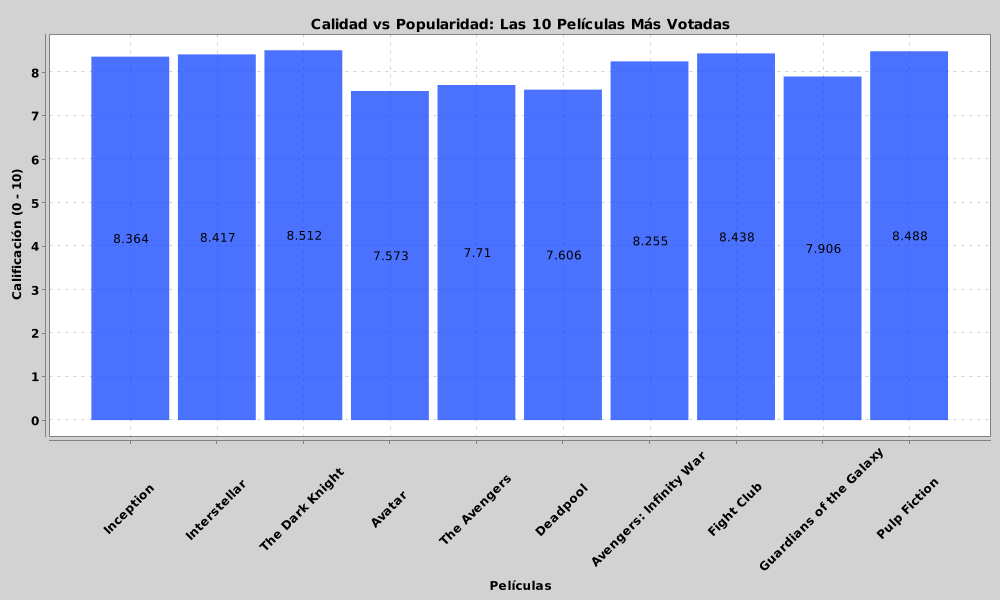

In [ ]:
import org.knowm.xchart.*;
import tech.tablesaw.api.Table;
import tech.tablesaw.api.Row;
import java.util.List;
import java.util.ArrayList;

// 1. Cargamos el archivo 
Table datos = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java-main/movies.csv");

// 2. Limpiamos y ordenamos
datos = datos.dropRowsWithMissingValues();
Table top10Populares = datos.sortDescendingOn("vote_count").first(10);

// 3. Extraemos datos
List<String> titulos = new ArrayList<>();
List<Double> calificaciones = new ArrayList<>();

for (Row fila : top10Populares) {
    titulos.add(fila.getString("title"));
    calificaciones.add(fila.getDouble("vote_average"));
}

// 4. Construimos el gráfico (Lo hacemos más alto y ancho)
CategoryChart grafico = new CategoryChartBuilder()
        .width(1000)
        .height(600) 
        .title("Calidad vs Popularidad: Las 10 Películas Más Votadas")
        .xAxisTitle("Películas")
        .yAxisTitle("Calificación (0 - 10)")
        .build();

// 5. AJUSTES VISUALES
grafico.getStyler().setXAxisLabelRotation(45);
grafico.getStyler().setLegendVisible(false);


grafico.getStyler().setHasAnnotations(true);

// 6. Metemos los datos al gráfico
grafico.addSeries("Calificación", titulos, calificaciones);

// 7. Dibuja el gráfico en tu Jupyter
BitmapEncoder.getBufferedImage(grafico)